In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv


In [2]:
!pip install nltk

# Import Lib


In [3]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
import os
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [4]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

# Data Cleaning


In [5]:
df=pd.read_csv("/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv")

In [6]:
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [7]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [9]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [10]:
df.sentiment.value_counts(normalize=True)

sentiment
positive    0.5
negative    0.5
Name: proportion, dtype: float64

In [11]:
df.sentiment.value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

<Axes: ylabel='count'>

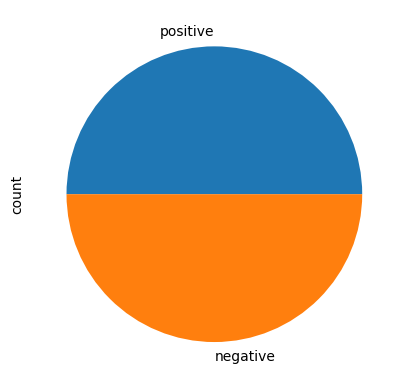

In [12]:
df.sentiment.value_counts().plot.pie()

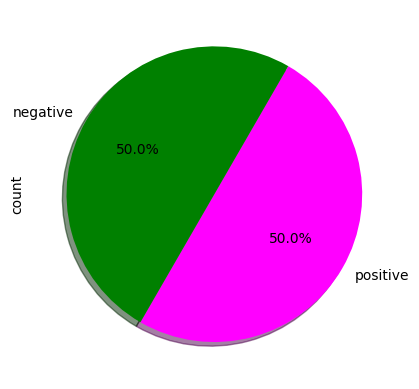

In [13]:
colors=['magenta','green','purple','orange']
df.sentiment.value_counts().plot.pie(colors=colors,autopct='%1.1f%%',shadow=True,startangle=60,counterclock=False)
plt.show()

# Remove punctuation
# Convert text upper into Lower

In [14]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [15]:
def remove_punct(text):
  #list comperhansion
  no_punct = "".join([char for char in text if char not in string.punctuation])
  return no_punct

#lambda function   ---> can have take any number of arguments ,but can only have one experssion
df['Review_NO_PUNCT'] = df['review'].apply(lambda x: remove_punct(x.lower()))
df.head()

,review,sentiment,Review_NO_PUNCT
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production br br the filmin...
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,negative,basically theres a family where a little boy j...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love in the time of money is a ...


In [16]:
print(df.review[0])
print(df.Review_NO_PUNCT[0])

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fac

In [17]:
df.head()

,review,sentiment,Review_NO_PUNCT
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production br br the filmin...
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,negative,basically theres a family where a little boy j...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love in the time of money is a ...


 # **Tokenization**

In [18]:
from nltk.tokenize import word_tokenize

In [19]:
def tokenization(text):
  token = word_tokenize(text)
  return token

df['Review_TOKEN'] = df['Review_NO_PUNCT'].apply(lambda x: tokenization(x))
df.head()

,review,sentiment,Review_NO_PUNCT,Review_TOKEN
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,"[one, of, the, other, reviewers, has, mentione..."
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production br br the filmin...,"[a, wonderful, little, production, br, br, the..."
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,"[i, thought, this, was, a, wonderful, way, to,..."
3,Basically there's a family where a little boy ...,negative,basically theres a family where a little boy j...,"[basically, theres, a, family, where, a, littl..."
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love in the time of money is a ...,"[petter, matteis, love, in, the, time, of, mon..."


In [20]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    filtered_words = [word for word in tokens if word not in stop_words]
    return filtered_words

df['Review_STOPWORDS'] = df['Review_TOKEN'].apply(remove_stopwords)

df.head()

,review,sentiment,Review_NO_PUNCT,Review_TOKEN,Review_STOPWORDS
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,"[one, of, the, other, reviewers, has, mentione...","[one, reviewers, mentioned, watching, 1, oz, e..."
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production br br the filmin...,"[a, wonderful, little, production, br, br, the...","[wonderful, little, production, br, br, filmin..."
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,"[i, thought, this, was, a, wonderful, way, to,...","[thought, wonderful, way, spend, time, hot, su..."
3,Basically there's a family where a little boy ...,negative,basically theres a family where a little boy j...,"[basically, theres, a, family, where, a, littl...","[basically, theres, family, little, boy, jake,..."
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love in the time of money is a ...,"[petter, matteis, love, in, the, time, of, mon...","[petter, matteis, love, time, money, visually,..."


In [21]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatization(tokens):
    lemma = [lemmatizer.lemmatize(word) for word in tokens]
    return lemma

df['Review_Lemma'] = df['Review_STOPWORDS'].apply(lemmatization)

df.head()

,review,sentiment,Review_NO_PUNCT,Review_TOKEN,Review_STOPWORDS,Review_Lemma
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,"[one, of, the, other, reviewers, has, mentione...","[one, reviewers, mentioned, watching, 1, oz, e...","[one, reviewer, mentioned, watching, 1, oz, ep..."
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production br br the filmin...,"[a, wonderful, little, production, br, br, the...","[wonderful, little, production, br, br, filmin...","[wonderful, little, production, br, br, filmin..."
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,"[i, thought, this, was, a, wonderful, way, to,...","[thought, wonderful, way, spend, time, hot, su...","[thought, wonderful, way, spend, time, hot, su..."
3,Basically there's a family where a little boy ...,negative,basically theres a family where a little boy j...,"[basically, theres, a, family, where, a, littl...","[basically, theres, family, little, boy, jake,...","[basically, there, family, little, boy, jake, ..."
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love in the time of money is a ...,"[petter, matteis, love, in, the, time, of, mon...","[petter, matteis, love, time, money, visually,...","[petter, matteis, love, time, money, visually,..."


In [22]:
print(df.columns)

Index(['review', 'sentiment', 'Review_NO_PUNCT', 'Review_TOKEN',
       'Review_STOPWORDS', 'Review_Lemma'],
      dtype='object')


In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(
    df['Review_Lemma'].apply(lambda x: ' '.join(x))
)

y = df['sentiment']

In [24]:
df.head()

,review,sentiment,Review_NO_PUNCT,Review_TOKEN,Review_STOPWORDS,Review_Lemma
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,"[one, of, the, other, reviewers, has, mentione...","[one, reviewers, mentioned, watching, 1, oz, e...","[one, reviewer, mentioned, watching, 1, oz, ep..."
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production br br the filmin...,"[a, wonderful, little, production, br, br, the...","[wonderful, little, production, br, br, filmin...","[wonderful, little, production, br, br, filmin..."
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,"[i, thought, this, was, a, wonderful, way, to,...","[thought, wonderful, way, spend, time, hot, su...","[thought, wonderful, way, spend, time, hot, su..."
3,Basically there's a family where a little boy ...,negative,basically theres a family where a little boy j...,"[basically, theres, a, family, where, a, littl...","[basically, theres, family, little, boy, jake,...","[basically, there, family, little, boy, jake, ..."
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love in the time of money is a ...,"[petter, matteis, love, in, the, time, of, mon...","[petter, matteis, love, time, money, visually,...","[petter, matteis, love, time, money, visually,..."


In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(
    df['Review_Lemma'].apply(lambda x: ' '.join(x))
)

y = df['sentiment']

In [26]:
y = df['sentiment']

In [27]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(y)

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [29]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [30]:
y_pred = model.predict(X_test)

In [31]:
print(model.score(X_train,y_train))
print(model.score(X_test,y_test))

0.9335
0.8964


In [32]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8964


In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.88      0.89      4961
           1       0.89      0.91      0.90      5039

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



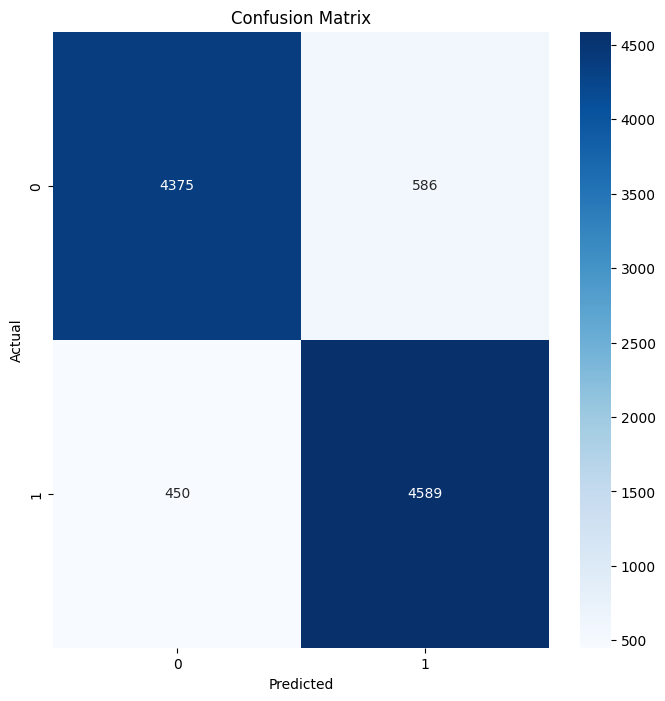

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

con = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,8))

sns.heatmap(con, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

In [35]:
import pickle

pickle.dump(model, open('Review.pkl', 'wb'))

pickle.dump(vectorizer, open('vectorizer.pkl', 'wb'))

In [36]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

MultinomialNB()

In [37]:
y_pred_nb = nb_model.predict(X_test)

In [38]:
print(model.score(X_train,y_train))
print(model.score(X_test,y_test))

0.9335
0.8964


In [39]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_nb))

Accuracy: 0.8691


In [40]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.86      0.89      0.87      4961
           1       0.88      0.85      0.87      5039

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



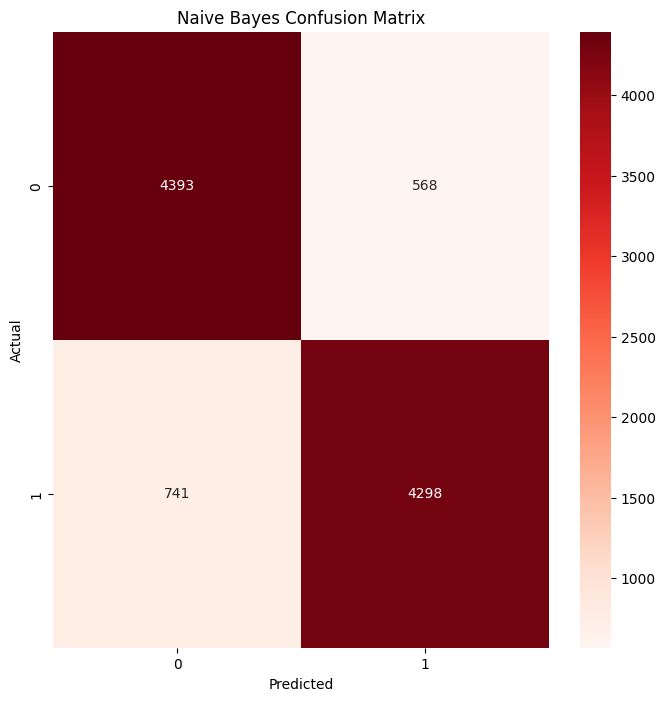

In [41]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

con = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(8,8))

sns.heatmap(con, annot=True, fmt='d', cmap='Reds')

plt.title('Naive Bayes Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

In [42]:
import pickle

pickle.dump(model, open('Review.pkl', 'wb'))
pickle.dump(vectorizer, open('vectorizer.pkl', 'wb'))


In [43]:
!pip install streamlit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 85.8 MB/s eta 0:00:00


In [44]:
import streamlit as st
import pickle

# Load model & vectorizer
model = pickle.load(open('Review.pkl', 'rb'))
vectorizer = pickle.load(open('vectorizer.pkl', 'rb'))

# Title
st.title("🎬 Movie Review Sentiment Analysis")

st.write("Enter a movie review and the model will predict if it's Positive or Negative")

# Input
user_input = st.text_area("Write your review here:")

# Button
if st.button("Predict"):
    
    # تحويل النص لـ vector
    vector = vectorizer.transform([user_input])

    # prediction
    prediction = model.predict(vector)

    # output
    if prediction[0] == 1:
        st.success("Positive Review 😊")
    else:
        st.error("Negative Review 😞")

2026-05-24 14:13:11.625 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-24 14:13:11.920 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-05-24 14:13:11.920 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-24 14:13:11.921 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-24 14:13:11.922 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-24 14:13:11.923 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-24 14:13:11.924 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-24 14:13:11.925 Thread 'MainThread': mi